In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = fetch_california_housing()

X = data.data
y = data.target

print("Feature Names:", data.feature_names)
print("Dataset Shape:", X.shape)

Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dataset Shape: (20640, 8)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (16512, 8)
Testing size: (4128, 8)


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [7]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

In [8]:
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2

In [9]:
lr_results = evaluate(y_test, y_pred_lr)
rf_results = evaluate(y_test, y_pred_rf)

print("Linear Regression Results:")
print("MAE:", lr_results[0])
print("MSE:", lr_results[1])
print("RMSE:", lr_results[2])
print("R2:", lr_results[3])

print("\nRandom Forest Results:")
print("MAE:", rf_results[0])
print("MSE:", rf_results[1])
print("RMSE:", rf_results[2])
print("R2:", rf_results[3])

Linear Regression Results:
MAE: 0.5332001304956566
MSE: 0.5558915986952442
RMSE: 0.7455813830127763
R2: 0.575787706032451

Random Forest Results:
MAE: 0.32754256845930246
MSE: 0.2553684927247781
RMSE: 0.5053399773665033
R2: 0.8051230593157366


In [10]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_results[0], rf_results[0]],
    "MSE": [lr_results[1], rf_results[1]],
    "RMSE": [lr_results[2], rf_results[2]],
    "R2 Score": [lr_results[3], rf_results[3]]
})

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.533200,0.555892,0.745581,0.575788
1,Random Forest,0.327543,0.255368,0.505340,0.805123


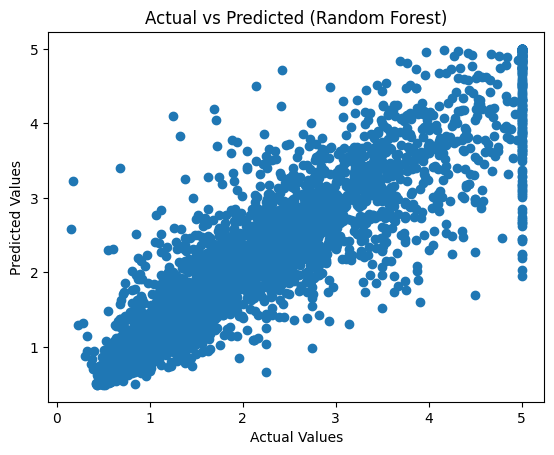

In [11]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")

# Save for LaTeX
plt.savefig("actual_vs_predicted.png")

plt.show()

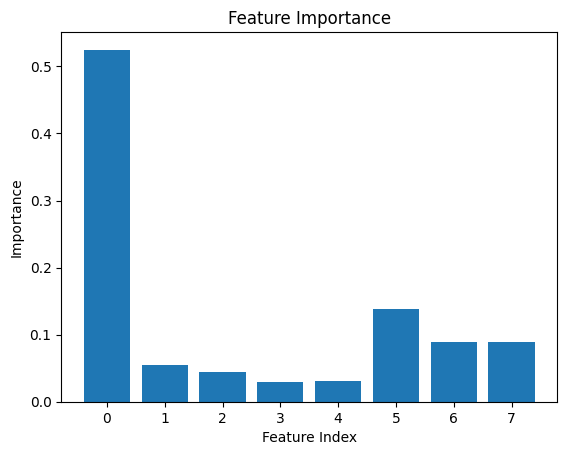

In [12]:
importances = rf.feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance")

# Save for LaTeX
plt.savefig("feature_importance.png")

plt.show()

In [13]:
from google.colab import files

files.download("actual_vs_predicted.png")
files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

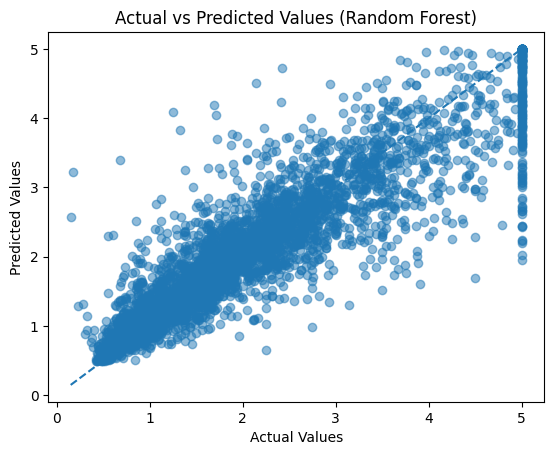

In [14]:
plt.figure()

plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')  # ideal line

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Random Forest)")

plt.savefig("actual_vs_predicted_improved.png")
plt.show()

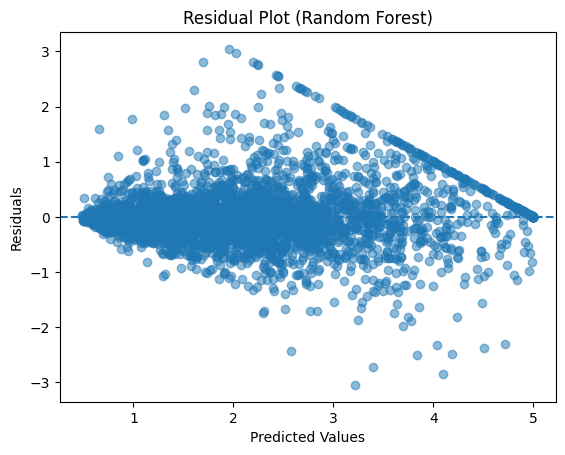

In [15]:
residuals = y_test - y_pred_rf

plt.figure()
plt.scatter(y_pred_rf, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")

plt.savefig("residual_plot.png")
plt.show()

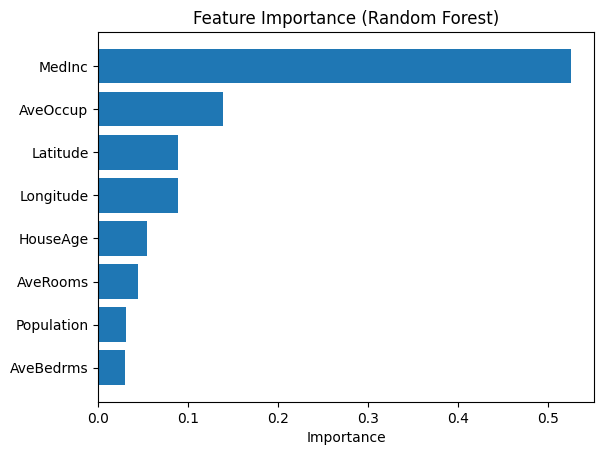

In [16]:
feature_names = data.feature_names
importances = rf.feature_importances_

indices = np.argsort(importances)

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")

plt.savefig("feature_importance_detailed.png")
plt.show()

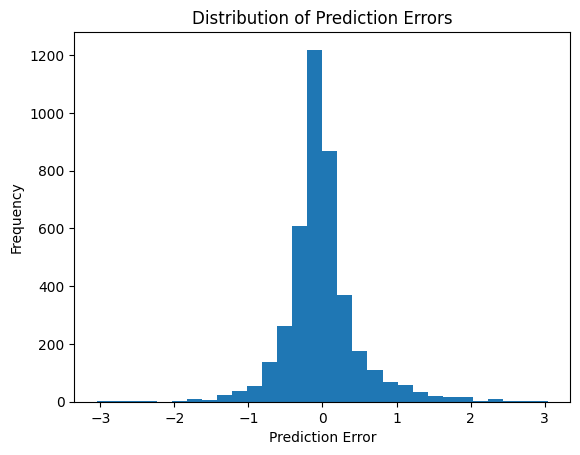

In [17]:
plt.figure()
plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.savefig("error_distribution.png")
plt.show()

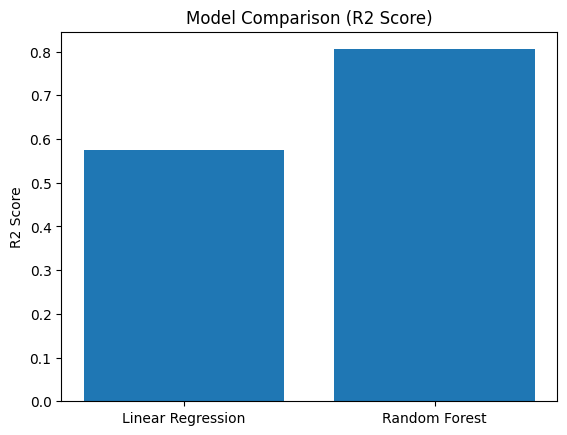

In [18]:
models = ["Linear Regression", "Random Forest"]
r2_scores = [lr_results[3], rf_results[3]]

plt.figure()
plt.bar(models, r2_scores)

plt.ylabel("R2 Score")
plt.title("Model Comparison (R2 Score)")

plt.savefig("model_comparison.png")
plt.show()

In [19]:
from google.colab import files

files.download("actual_vs_predicted_improved.png")
files.download("residual_plot.png")
files.download("feature_importance_detailed.png")
files.download("error_distribution.png")
files.download("model_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

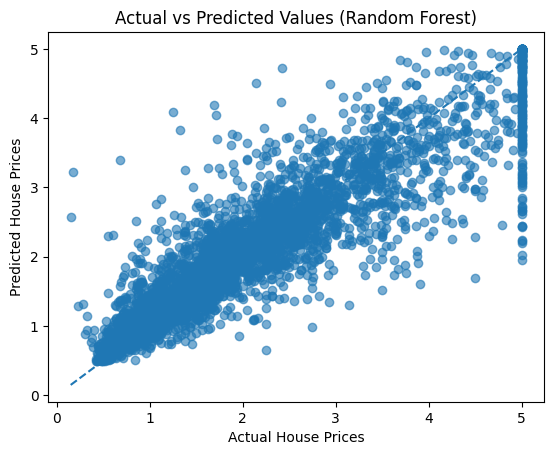

In [20]:
plt.figure()

plt.scatter(y_test, y_pred_rf, alpha=0.6)

# Ideal line (perfect prediction)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted Values (Random Forest)")

plt.savefig("actual_vs_predicted.png")
plt.show()

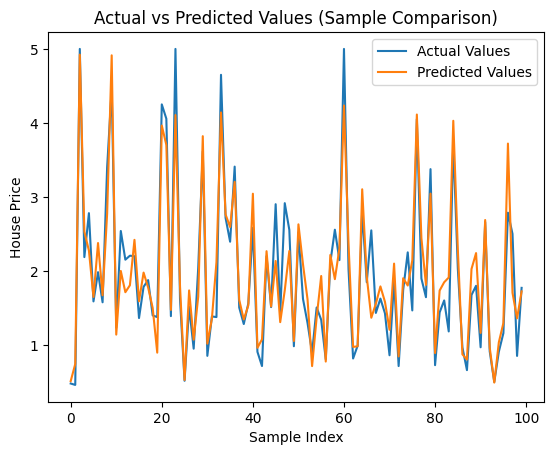

In [21]:
# Take a small sample for clarity
sample_size = 100

plt.figure()

plt.plot(y_test[:sample_size], label="Actual Values")
plt.plot(y_pred_rf[:sample_size], label="Predicted Values")

plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.title("Actual vs Predicted Values (Sample Comparison)")

plt.legend()

plt.savefig("line_comparison.png")
plt.show()

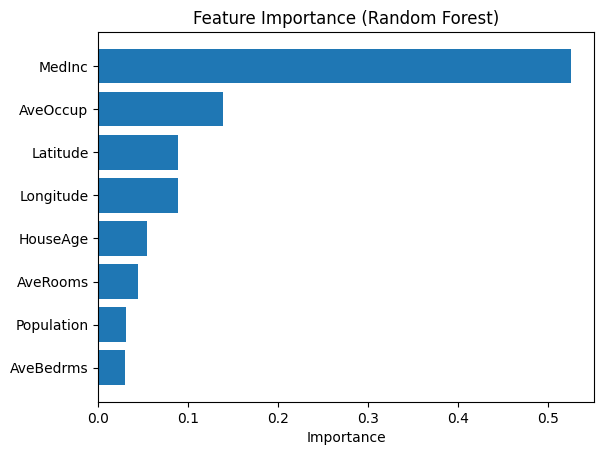

In [22]:
feature_names = data.feature_names
importances = rf.feature_importances_

indices = np.argsort(importances)

plt.figure()

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")

plt.savefig("feature_importance.png")
plt.show()

In [24]:
from google.colab import files

files.download("actual_vs_predicted.png")
files.download("line_comparison.png")
files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert dataset to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df["Target"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [30]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1O4mtpkpd-xawgElJx1JEBNKYDwGpE6ge2g27AzRnBcQ/edit#gid=0


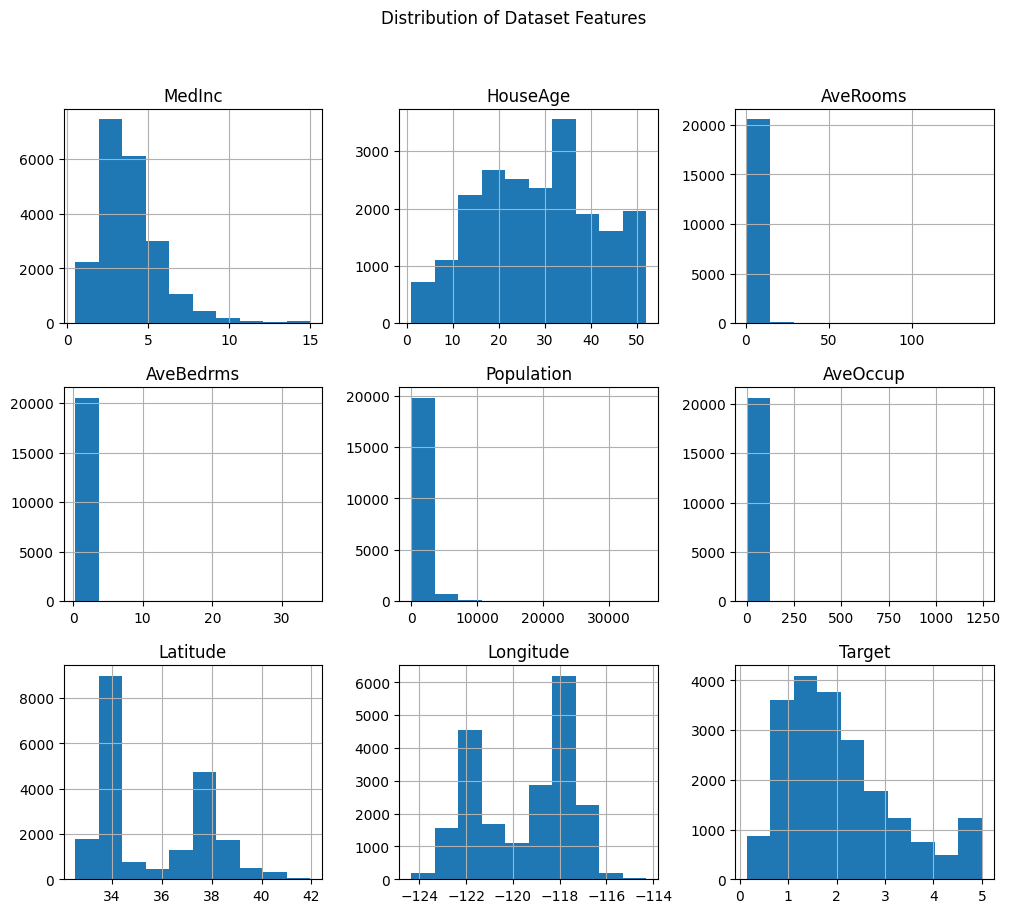

In [26]:
df.hist(figsize=(12, 10))
plt.suptitle("Distribution of Dataset Features")

plt.savefig("feature_distribution.png")
plt.show()

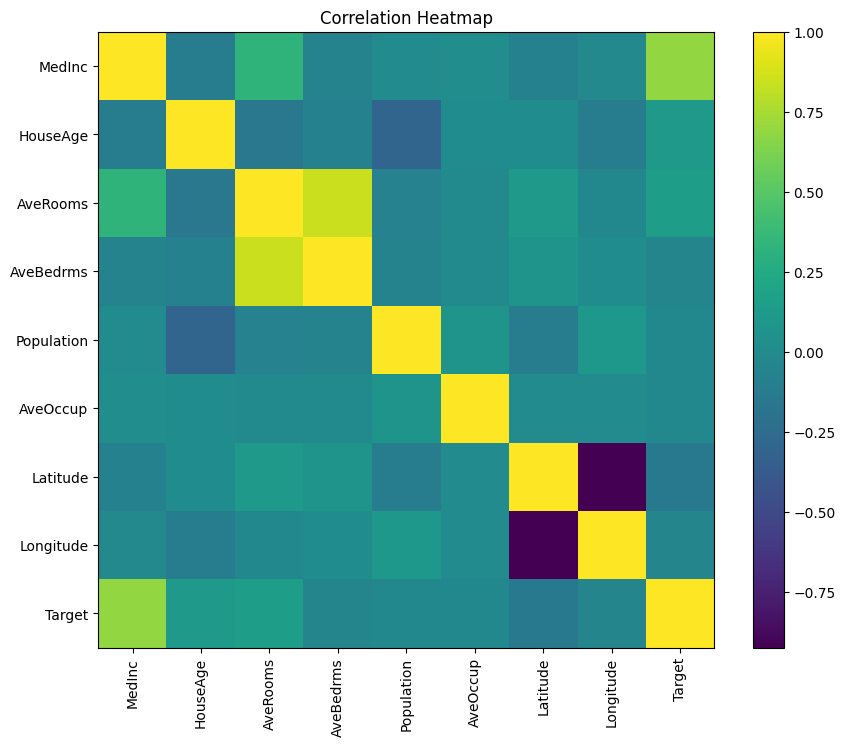

In [27]:
import numpy as np

corr = df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")
plt.show()

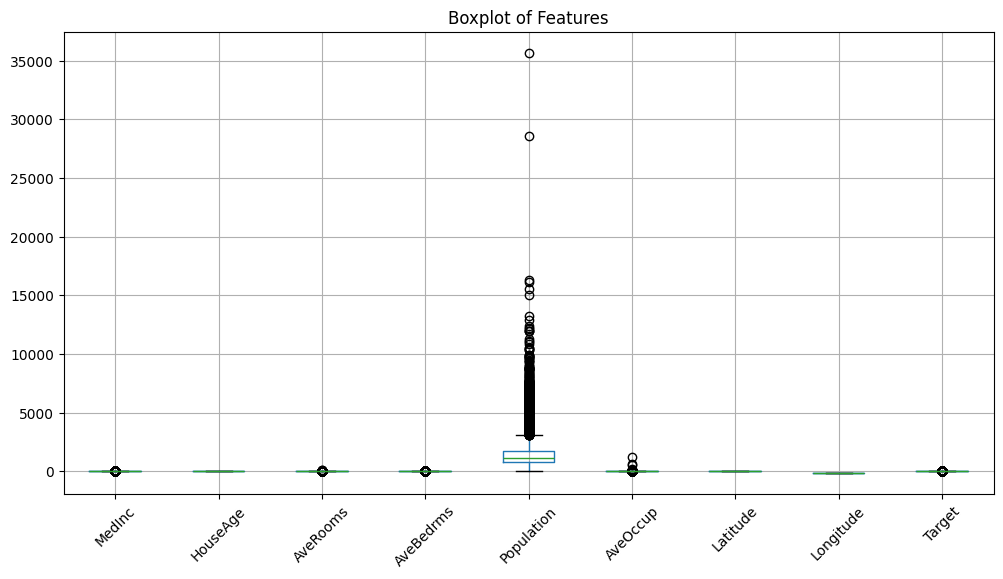

In [29]:
plt.figure(figsize=(12, 6))

df.boxplot(rot=45)

plt.title("Boxplot of Features")

plt.savefig("boxplot.png")
plt.show()